# 单轴分组气泡图是散点图的变体之一，适合展示多组一维数据的数值大小与分布状况~
# 这个可以用来展示某几列特征之间的协同变化关系


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

In [2]:
# 设置样式
try:
    plt.style.use("scatter.mplstyle")
except:
    pass
# 使用Nature常用的无衬线字体，Ubuntu系统兼容
plt.rcParams["font.sans-serif"] = ["Liberation Sans", "Arial", "Helvetica", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

In [3]:

# 是否读取自定义数据集
read_custom_data = False

if read_custom_data:
    df = pd.read_csv("data.csv")
else:
    # 创建模拟数据
    np.random.seed(2)
    categories = ["data1", "data2", "data3", "data4", "data5"]
    num_points = 20
    category_colors = ["#d36a87", "#e5c679", "#83b6b5", "#619cf5", "#a596ee"]

    bubble_rows = []

    for index, category in enumerate(categories):
        x_values = np.random.uniform(0, 10, num_points)
        y_positions = [index] * num_points
        bubble_sizes = np.random.randint(10, 1500, size=num_points)
        color_list = [category_colors[index]] * num_points

        for x, y, size, color in zip(x_values, y_positions, bubble_sizes, color_list):
            bubble_rows.append([category, x, y, size, color])

    bubble_df = pd.DataFrame(bubble_rows, columns=["category", "x", "y", "size", "color"])
    # bubble_df.to_csv("data.csv", index=False)
    # 读取数据（模拟场景下直接用生成的bubble_df）
    df = bubble_df


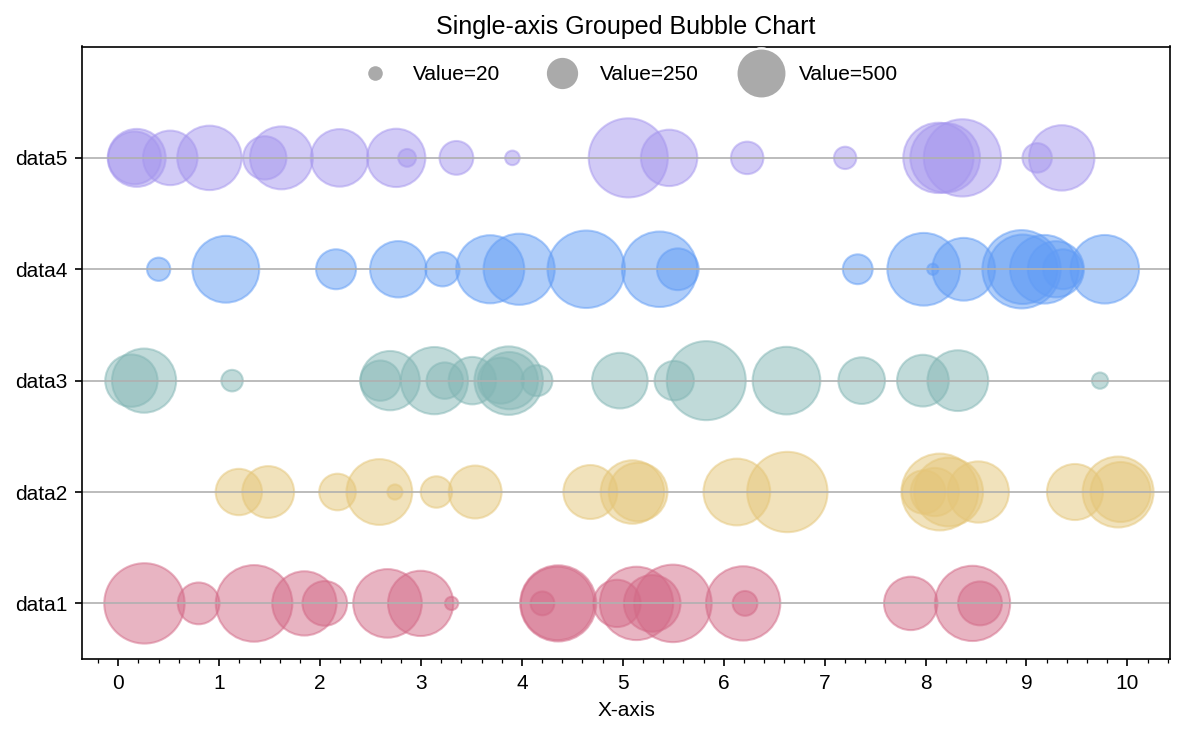

In [ ]:
# Create chart
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

categories = df["category"].unique()
# Draw bubble chart
for category in categories:
    category_data = df[df["category"] == category]
    ax.scatter(
        category_data["x"],
        category_data["y"],
        s=category_data["size"],
        c=category_data["color"],
        alpha=0.5,
        label=category
    )

# Set axes and title
ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.2))
ax.set_ylim(-0.5, len(categories))
ax.grid(axis='y')
ax.set_xlabel("X-axis")
ax.set_title("Single-axis Grouped Bubble Chart")

# Legend: bubble size explanation
def create_marker_legend(color, label, size):
    return Line2D(
        [0], [0],
        marker="o",
        color="#ffffff",
        markersize=size,
        markerfacecolor=color,
        markeredgecolor="#ffffff",
        label=label,
    )

size_legend_items = [
    create_marker_legend("#aaaaaa", "Value=20", 8),
    create_marker_legend("#aaaaaa", "Value=250", 16),
    create_marker_legend("#aaaaaa", "Value=500", 24),
]

legend_size = ax.legend(handles=size_legend_items, loc="upper center", ncol=3)
legend_size.get_frame().set_edgecolor("#ffffff")
ax.add_artist(legend_size)

plt.tight_layout()

plt.savefig('./Single-axis Grouped Bubble Chart.pdf', dpi=300, bbox_inches='tight')

plt.show()